<div style="color:#FFFFFF;background-color:Red;text-align:center;padding-top: 50px; padding-right: 30px; padding-bottom: 50px; padding-left: 80px;border-radius:10px 10px 10px 10px;">
    <h1>
        Assignment 7: SVM On Donor Choose
    </h1>
</div>

### [Task-1] 
#### [1] Apply Support Vector Machines(SGDClassifier with hinge loss: Linear SVM) on these feature sets
- Set 1: categorical, numerical features + project_title(BOW) + preprocessed_eassay (BOW)
- Set 2: categorical, numerical features + project_title(TFIDF)+ preprocessed_eassay (TFIDF)
- Set 3: categorical, numerical features + project_title(AVG W2V)+ preprocessed_eassay (AVG W2V)
- Set 4: categorical, numerical features + project_title(TFIDF W2V)+ preprocessed_eassay (TFIDF W2V)


<h4> [2] The hyper paramter tuning (best alpha in range [10<sup>-4</sup> to 10<sup>4</sup> ], and the best penalty among 'l1', 'l2')</h4>

- Find the best hyper parameter which will give the maximum AUC value
- Find the best hyper paramter using k-fold cross validation or simple cross validation data
- Use gridsearch cv or randomsearch cv or you can also write your own for loops to do this task of hyperparameter tuning

#### [3] Representation of results
- You need to plot the performance of model both on train data and cross validation data for each hyper parameter, like shown in the figure. 
- Once after you found the best hyper parameter, you need to train your model with it, and find the AUC on test data and plot the ROC curve on both train and test. 
- Along with plotting ROC curve, you need to print the confusion matrix with predicted and original labels of test data points. Please visualize your confusion matrices using seaborn heatmaps. 

### [Task-2] 
#### [1] Apply the Support Vector Machines on these features by finding the best hyper paramter as suggested in step 2 and step3
<b>Consider these set of features [Set 5] </b>:
- school_state : categorical data
- clean_categories : categorical data
- clean_subcategories : categorical data
- project_grade_category :categorical data
- teacher_prefix : categorical data
- quantity : numerical data
- teacher_number_of_previously_posted_projects : numerical data
- price : numerical data
- sentiment score's of each of the essay : numerical data
- number of words in the title : numerical data
- number of words in the combine essays : numerical data
- Apply TruncatedSVD on TfidfVectorizer of essay text, choose the number of components (`n_components`) using elbow method : numerical data

#### Conclusion
- You need to summarize the results at the end of the notebook, summarize it in the table format. To print out a table please refer to this prettytable library (Geeks for Geeks )<a href="https://www.geeksforgeeks.org/creating-tables-with-prettytable-library-python/"> Link </a>


#### Note: Data Leakage
- There will be an issue of data-leakage if you vectorize the entire data and then split it into train/cv/test.
- To avoid the issue of data-leakage, make sure to split your data first and then vectorize it.
- While vectorizing your data, apply the method fit_transform() on you train data, and apply the method transform() on cv/test data.
- For more details please go through this link. <a href="https://machinelearningmastery.com/data-preparation-without-data-leakage/"> Link </a>

<div style="color:#FFFFFF;background-color:Red;text-align:center;padding-top: 50px; padding-right: 30px; padding-bottom: 50px; padding-left: 80px;border-radius:10px 10px 10px 10px;">
    <h1>
        Assignment 7: We start here
    </h1>
</div>

## [1] Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


df= pd.read_csv(r"C:\Users\Faizan_Shakeel\Desktop\Notebooks\Module 3\M302 KNN\Preprocessed_DonorsChoose_dataset.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109248 entries, 0 to 109247
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   id                                            109248 non-null  object 
 1   teacher_prefix                                109248 non-null  object 
 2   school_state                                  109248 non-null  object 
 3   project_grade_category                        109248 non-null  object 
 4   project_subject_categories                    109248 non-null  object 
 5   project_subject_subcategories                 109248 non-null  object 
 6   teacher_number_of_previously_posted_projects  109248 non-null  int64  
 7   project_is_approved                           109248 non-null  int64  
 8   price                                         109248 non-null  float64
 9   quantity                                      10

In [5]:
df.head(3)

,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary
0,p253737,mrs,in,grades_prek_2,literacy_language,esl_literacy,0,0,154.60,23,educational support english learners home,students english learners working english seco...,students_need_opportunities_practice_beginning...,0
1,p258326,mr,fl,grades_6_8,history_civics_health_sports,civics_government_teamsports,7,1,299.00,1,wanted projector hungry learners,students arrive school eager learn polite gene...,students_need_projector_help_viewing_education...,0
2,p182444,ms,az,grades_6_8,health_sports,health_wellness_teamsports,1,0,516.85,22,soccer equipment awesome middle school students,true champions not always ones win guts mia ha...,students_need_shine_guards_athletic_socks_socc...,0


In [7]:
#Features Basic Details inspections
a= df.columns

for i in range (0,len(a)):
    print(a[i])
    print(f"Cardinality: {df[a[i]].nunique()}")
    print(f"Number of null values: {df[a[i]].isnull().sum()}")
    print(f"DataType: {df[a[i]].dtype}")
    print("=="*30)
    print()

id
Cardinality: 109248
Number of null values: 0
DataType: object

teacher_prefix
Cardinality: 5
Number of null values: 0
DataType: object

school_state
Cardinality: 51
Number of null values: 0
DataType: object

project_grade_category
Cardinality: 4
Number of null values: 0
DataType: object

project_subject_categories
Cardinality: 51
Number of null values: 0
DataType: object

project_subject_subcategories
Cardinality: 401
Number of null values: 0
DataType: object

teacher_number_of_previously_posted_projects
Cardinality: 374
Number of null values: 0
DataType: int64

project_is_approved
Cardinality: 2
Number of null values: 0
DataType: int64

price
Cardinality: 45242
Number of null values: 0
DataType: float64

quantity
Cardinality: 332
Number of null values: 0
DataType: int64

cleaned_titles
Cardinality: 91442
Number of null values: 43
DataType: object

cleaned_essays
Cardinality: 108314
Number of null values: 0
DataType: object

cleaned_summary
Cardinality: 107885
Number of null values:

In [8]:
#sampling 40% data for this assignemnt
df.shape
df1 = df.sample(frac=0.40)
df1.shape

(43699, 14)

In [9]:
y= df1['project_is_approved']
df1.drop(columns=['project_is_approved'], inplace= True)

print(df1.shape)
df1.head(3)

(43699, 13)


,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary
84193,p109209,mrs,ca,grades_3_5,health_sports_specialneeds,health_wellness_specialneeds,4,54.45,3,keep em movin 2,school brand new emphasis project based learni...,students_need_flexible_seating_options_help_fo...,0
99402,p245829,mr,ca,grades_9_12,appliedlearning_history_civics,college_careerprep_socialsciences,11,6.49,50,usb optical mice needed history classroom,students extremely hardworking dedicated impro...,students_need_50_jetech_3_button_wired_usb_opt...,1
17935,p004814,mr,tn,grades_9_12,health_sports_specialneeds,health_wellness_specialneeds,0,259.64,3,mind body motion,believe every student deserves exceptional edu...,students_need_hokki_stools_order_appropriately...,0


# [2] Feturizations

we already have preprocesses data, and can we done using [Amazon Fine Food Review Chapter is detail}

In [10]:
# Before Feturizaton, it's good practice to split data in test and train to avoid [Data Leakge]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( df1, y, test_size=0.20, random_state=42)
X_train, X_cv, y_train, y_cv= train_test_split( X_train, y_train, test_size=0.10, random_state=42)

print("Training data shape:", X_train.shape, y_train.shape)
print("Cross Val data shape:", X_cv.shape, y_cv.shape)
print("Test data shape:", X_test.shape, y_test.shape)

Training data shape: (31463, 13) (31463,)
Cross Val data shape: (3496, 13) (3496,)
Test data shape: (8740, 13) (8740,)


### Handling skewness -oversampling traing data

In [11]:
print("Training target variable distribution:\n", y_train.value_counts())

from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(sampling_strategy='minority', random_state=42)
X_train, y_train = ros.fit_resample(X_train, y_train)


print(y_train.value_counts())
print(X_train.shape)

Training target variable distribution:
 1    26764
0     4699
Name: project_is_approved, dtype: int64
1    26764
0    26764
Name: project_is_approved, dtype: int64
(53528, 13)


### 2.1 Handling Numarical Features

In [12]:
# 1 Getting list of numarical features
def get_numerical_columns(df):
    numerical_cols = []
    for col in df.columns:
        if df[col].dtype in ['int64', 'float64']:
            numerical_cols.append(col)
    return numerical_cols

num_cols= get_numerical_columns(X_train)
print(num_cols)

['teacher_number_of_previously_posted_projects', 'price', 'quantity', 'isdigit_summary']


array([[<Axes: title={'center': 'teacher_number_of_previously_posted_projects'}>,
        <Axes: title={'center': 'price'}>],
       [<Axes: title={'center': 'quantity'}>,
        <Axes: title={'center': 'isdigit_summary'}>]], dtype=object)

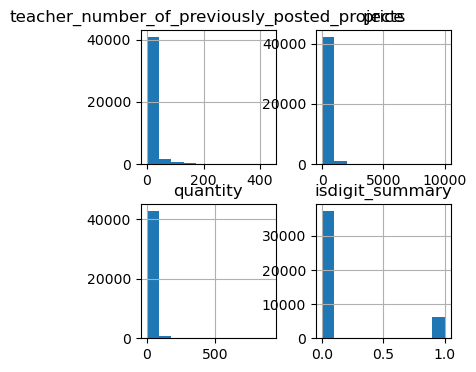

In [13]:
#checking distributions of numarical features
df1[num_cols].hist(figsize=(4,4))

In [17]:
#minmax scaling
from sklearn.preprocessing import MinMaxScaler
scalar = MinMaxScaler()

scalar.fit(X_train[num_cols]) #fit has happen on only train data

X_train_nc_scaled = scalar.transform(X_train[num_cols])
X_test_nc_scaled  = scalar.transform(X_test[num_cols])
X_cv_nc_scaled    = scalar.transform(X_cv[num_cols])

In [139]:
#converting all to csr matrix, later use hstack
from scipy.sparse import hstack, csr_matrix

X_train_nc_scaled_csr = csr_matrix(X_train_nc_scaled)
X_test_nc_scaled_csr  = csr_matrix(X_test_nc_scaled)
X_cv_nc_scaled_csr    = csr_matrix(X_cv_nc_scaled)

### 2.1 Handling Categorical Features

In [42]:
# 1 Getting list of categroical features
def get_categorical_columns(df):
    cat_cols = []
    for i in df.columns:
        if df[i].dtype in ['object'] and df[i].nunique()< 405:
            cat_cols.append(i)
    return cat_cols

Cat_cols= get_categorical_columns(df)
print(Cat_cols)

['teacher_prefix', 'school_state', 'project_grade_category', 'project_subject_categories', 'project_subject_subcategories']


In [43]:
a= Cat_cols
for i in range (0,len(a)):
    print(a[i])
    print(f"Cardinality: {df[a[i]].nunique()}")
    print(f"Number of null values: {df[a[i]].isnull().sum()}")
    print(f"DataType: {df[a[i]].dtype}")
    print("=="*30)
    print()

teacher_prefix
Cardinality: 5
Number of null values: 0
DataType: object

school_state
Cardinality: 51
Number of null values: 0
DataType: object

project_grade_category
Cardinality: 4
Number of null values: 0
DataType: object

project_subject_categories
Cardinality: 51
Number of null values: 0
DataType: object

project_subject_subcategories
Cardinality: 401
Number of null values: 0
DataType: object



<b> Using Countvectorizor to do ohe (one hot encoding)

In [57]:
print(Cat_cols)

['teacher_prefix', 'school_state', 'project_grade_category', 'project_subject_categories', 'project_subject_subcategories']


In [69]:
#teacher_prefix -tp
from sklearn.feature_extraction.text import CountVectorizer
cvect_tp = CountVectorizer()

cvect_tp.fit(X_train[Cat_cols[0]])

train_tp_ohe = cvect_tp.transform(X_train[Cat_cols[0]])
test_tp_ohe = cvect_tp.transform(X_test[Cat_cols[0]])
cv_tp_ohe = cvect_tp.transform(X_cv[Cat_cols[0]])

In [75]:
#'school_state' -ss
from sklearn.feature_extraction.text import CountVectorizer
cvect_ss = CountVectorizer()

cvect_ss.fit(X_train[Cat_cols[1]])

train_ss_ohe = cvect_ss.transform(X_train[Cat_cols[1]])
test_ss_ohe = cvect_ss.transform(X_test[Cat_cols[1]])
cv_ss_ohe = cvect_ss.transform(X_cv[Cat_cols[1]])

In [81]:
#'project_grade_category"-pgc
from sklearn.feature_extraction.text import CountVectorizer
cvect_pgc = CountVectorizer()

cvect_pgc.fit(X_train[Cat_cols[2]])    #fit has happen on train data only

train_pgc_ohe = cvect_pgc.transform(X_train[Cat_cols[2]])
test_pgc_ohe = cvect_pgc.transform(X_test[Cat_cols[2]])
cv_pgc_ohe = cvect_pgc.transform(X_cv[Cat_cols[2]])

print(train_pgc_ohe.shape, test_pgc_ohe.shape, cv_pgc_ohe.shape)

(53528, 4) (8740, 4) (3496, 4)


In [82]:
# 'project_subject_categories'-psc
cvect_psc = CountVectorizer()

cvect_psc.fit(X_train[Cat_cols[3]])    #fit has happen on train data only

train_psc_ohe = cvect_psc.transform(X_train[Cat_cols[3]])
test_psc_ohe = cvect_psc.transform(X_test[Cat_cols[3]])
cv_psc_ohe = cvect_psc.transform(X_cv[Cat_cols[3]])

print(train_psc_ohe.shape, test_psc_ohe.shape, cv_psc_ohe.shape)

(53528, 50) (8740, 50) (3496, 50)


In [84]:
# 'project_subject_subcategories'- pssc
cvect_pssc = CountVectorizer()

cvect_pssc.fit(X_train[Cat_cols[4]])    #fit has happen on train data only

train_pssc_ohe = cvect_pssc.transform(X_train[Cat_cols[4]])
test_pssc_ohe = cvect_pssc.transform(X_test[Cat_cols[4]])
cv_pssc_ohe = cvect_pssc.transform(X_cv[Cat_cols[4]])

print(train_pssc_ohe.shape, test_pssc_ohe.shape, cv_pssc_ohe.shape)

(53528, 357) (8740, 357) (3496, 357)


Now we have:
- train_tp_ohe, train_ss_ohe, train_pgc_ohe, train_psc_ohe, train_pssc_ohe
- test_tp_ohe, test_ss_ohe, test_pgc_ohe, test_psc_ohe, test_pssc_ohe
- cv_tp_ohe, cv_ss_ohe, cv_pgc_ohe, cv_psc_ohe, cv_pssc_ohe

In [149]:
#stacking all to, later use hstack
from scipy.sparse import hstack, csr_matrix

X_train_catcols_ohe_csr = hstack([train_tp_ohe, train_ss_ohe, train_pgc_ohe, train_psc_ohe, train_pssc_ohe])
X_test_catcols_ohe_csr  = hstack([test_tp_ohe, test_ss_ohe, test_pgc_ohe, test_psc_ohe, test_pssc_ohe])
X_cv_catcols_ohe_csr    = hstack([cv_tp_ohe, cv_ss_ohe, cv_pgc_ohe, cv_psc_ohe, cv_pssc_ohe])

X_train_catcols_ohe_csr.shape                       #shape (357+50+4+56)

(53528, 467)

## [3] Handling Text Features 
<b>['cleaned_titles', 'cleaned_essays']

In [110]:
#2 checking null values one by one and imputing: missing value as info
txt_cols= ['cleaned_titles', 'cleaned_essays']
d= X_train  #chenge for all

a= txt_cols[0]
print("Is Null in ",a,":", d[a].isnull().sum())
print("Cardinality ",a,":", d[a].nunique())
print(d[a])


#imputing: missing value-as info
if d[a].isnull().sum()>0:
    d[a]= d[a].fillna('Unavilable')
    print('Imputed')
else:
    print('no null values')

Is Null in  cleaned_titles : 0
Cardinality  cleaned_titles : 28236
no null values


### [3.1] BOW Feturization

In [111]:
#'cleaned_titles'-ct    :: ['cleaned_titles', 'cleaned_essays']

from sklearn.feature_extraction.text import CountVectorizer
cvect_ct= CountVectorizer(min_df=10)

cvect_ct.fit(X_train[txt_cols[0]])  #fit happen on train data only

train_ct_bow= cvect_ct.transform(X_train[txt_cols[0]])
test_ct_bow = cvect_ct.transform(X_test[txt_cols[0]])
cv_ct_bow   = cvect_ct.transform(X_cv[txt_cols[0]])


print("Shapes of Train, Test and CV resp: ",train_ct_bow.shape, test_ct_bow.shape, cv_ct_bow.shape )

Shapes of Train, Test and CV resp:  (53528, 2256) (8740, 2256) (3496, 2256)


In [112]:
#'cleaned_essays'-ess :: ['cleaned_titles', 'cleaned_essays']

from sklearn.feature_extraction.text import CountVectorizer
cvect_ct_ess= CountVectorizer(min_df=10, max_features=5000)

cvect_ct_ess.fit(X_train[txt_cols[1]])  #fit happen on train data only

train_ess_bow= cvect_ct_ess.transform(X_train[txt_cols[1]])
test_ess_bow = cvect_ct_ess.transform(X_test[txt_cols[1]])
cv_ess_bow   = cvect_ct_ess.transform(X_cv[txt_cols[1]])


print("Shapes of Train, Test and CV resp: ",train_ess_bow.shape, test_ess_bow.shape, cv_ess_bow.shape )

Shapes of Train, Test and CV resp:  (53528, 5000) (8740, 5000) (3496, 5000)


### [3.2] tf-idf Feturization

In [115]:
#'cleaned_titles'-ct    :: ['cleaned_titles', 'cleaned_essays']

from sklearn.feature_extraction.text import TfidfVectorizer

tfidfvect_ct= TfidfVectorizer(min_df=10)

tfidfvect_ct.fit(X_train[txt_cols[0]])  #fit happen on train data only

train_ct_tfidf= tfidfvect_ct.transform(X_train[txt_cols[0]])
test_ct_tfidf = tfidfvect_ct.transform(X_test[txt_cols[0]])
cv_ct_tfidf   = tfidfvect_ct.transform(X_cv[txt_cols[0]])


print("Shapes of Train, Test and CV resp: ",train_ct_tfidf.shape, test_ct_tfidf.shape, cv_ct_tfidf.shape )

Shapes of Train, Test and CV resp:  (53528, 2256) (8740, 2256) (3496, 2256)


In [166]:
#'cleaned_essays'-ess :: ['cleaned_titles', 'cleaned_essays']

tfidfvect_ct_ess= CountVectorizer(min_df=10, max_features=5000)
tfidfvect_ct_ess.fit(X_train[txt_cols[1]])  #fit happen on train data only


train_ess_tfidf= tfidfvect_ct_ess.transform(X_train[txt_cols[1]])
test_ess_tfidf = tfidfvect_ct_ess.transform(X_test[txt_cols[1]])
cv_ess_tfidf   = tfidfvect_ct_ess.transform(X_cv[txt_cols[1]])


print("Shapes of Train, Test and CV resp: ",train_ess_tfid.shape, test_ess_tfid.shape, cv_ess_tfid.shape )

Shapes of Train, Test and CV resp:  (53528, 5000) (8740, 5000) (3496, 5000)


### [3.3] avg word2vec

In [119]:
#avg_word2vech
from gensim.models import Word2Vec

titles = X_train['cleaned_titles'].apply(lambda x: x.split()).tolist()
essays = X_train['cleaned_essays'].apply(lambda x: x.split()).tolist()
all_texts = titles + essays                        #to train word2veck

# Train Word2Vec model
w2v_model = Word2Vec(sentences=all_texts, vector_size=100, window=5, min_count=1, workers=4)

# Average Word2Vec
def avg_word2vec(text, model):
    words = text.split()
    word_vecs = [model.wv[word] for word in words if word in model.wv]
    if len(word_vecs) == 0:
        return np.zeros(model.vector_size)
    return np.mean(word_vecs, axis=0)

# Apply average Word2Vec to cleaned essay
avg_w2v_titles_train= X_train['cleaned_titles'].apply(lambda x: avg_word2vec(x, w2v_model))
avg_w2v_titles_test = X_test['cleaned_titles'].apply(lambda x: avg_word2vec(x, w2v_model))
avg_w2v_titles_cv   = X_cv['cleaned_titles'].apply(lambda x: avg_word2vec(x, w2v_model))



# Apply average Word2Vec to cleaned essay
avg_w2v_essays_train = X_train['cleaned_essays'].apply(lambda x: avg_word2vec(x, w2v_model))
avg_w2v_essays_test  = X_test['cleaned_essays'].apply(lambda x: avg_word2vec(x, w2v_model))
avg_w2v_essays_cv    = X_cv['cleaned_essays'].apply(lambda x: avg_word2vec(x, w2v_model))

In [174]:
#2. Series to matrix and then csr
import numpy as np
from scipy.sparse import csr_matrix

# Convert series of numpy arrays to a dense matrix
def series_to_matrix(series):
    return np.vstack(series.to_numpy())

# Convert the dense matrix to a CSR matrix
def convert_to_csr(matrix):
    return csr_matrix(matrix)



# Prepare the data
avg_w2v_titles_train_matrix = series_to_matrix(avg_w2v_titles_train)
avg_w2v_titles_test_matrix = series_to_matrix(avg_w2v_titles_test)
avg_w2v_titles_cv_matrix = series_to_matrix(avg_w2v_titles_cv)

avg_w2v_essays_train_matrix = series_to_matrix(avg_w2v_essays_train)
avg_w2v_essays_test_matrix = series_to_matrix(avg_w2v_essays_test)
avg_w2v_essays_cv_matrix = series_to_matrix(avg_w2v_essays_cv)




# Convert to CSR matrices
csr_avg_w2v_titles_train = convert_to_csr(avg_w2v_titles_train_matrix)
csr_avg_w2v_titles_test = convert_to_csr(avg_w2v_titles_test_matrix)
csr_avg_w2v_titles_cv = convert_to_csr(avg_w2v_titles_cv_matrix)

csr_avg_w2v_essays_train = convert_to_csr(avg_w2v_essays_train_matrix)
csr_avg_w2v_essays_test = convert_to_csr(avg_w2v_essays_test_matrix)
csr_avg_w2v_essays_cv = convert_to_csr(avg_w2v_essays_cv_matrix)

# Now you can use these CSR matrices to train your model

### [3.4] tfidf weighted word2vec

In [124]:
# TF-IDF weighted Word2Vec- used above trained Word2veck
tfidf = TfidfVectorizer()

tfidf.fit(X_train['cleaned_titles'] + ' ' + X_train['cleaned_essays'])
tfidf_vocab = tfidf.vocabulary_
tfidf_weights = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))  #https://www.w3schools.com/python/ref_func_zip.asp

def tfidf_w2v(text, model, tfidf_vocab, tfidf_weights):
    words = text.split()
    word_vecs = []
    for word in words:
        if word in model.wv and word in tfidf_vocab:
            word_vecs.append(model.wv[word] * tfidf_weights[word])
    if len(word_vecs) == 0:
        return np.zeros(model.vector_size)
    return np.mean(word_vecs, axis=0)



# Apply TF-IDF weighted Word2Vec to the cleaned_titles
tfidf_w2v_titles_train= matrix(X_train['cleaned_titles'].apply(lambda x: tfidf_w2v(x, w2v_model, tfidf_vocab, tfidf_weights))
tfidf_w2v_titles_test = X_test['cleaned_titles'].apply(lambda x: tfidf_w2v(x, w2v_model, tfidf_vocab, tfidf_weights))
tfidf_w2v_titles_cv   = X_cv['cleaned_titles'].apply(lambda x: tfidf_w2v(x, w2v_model, tfidf_vocab, tfidf_weights))



# Apply TF-IDF weighted Word2Vec to the cleaned_essay
tfidf_w2v_essays_train= X_train['cleaned_essays'].apply(lambda x: tfidf_w2v(x, w2v_model, tfidf_vocab, tfidf_weights))
tfidf_w2v_essays_test = X_test['cleaned_essays'].apply(lambda x: tfidf_w2v(x, w2v_model, tfidf_vocab, tfidf_weights))
tfidf_w2v_essays_cv   = X_cv['cleaned_essays'].apply(lambda x: tfidf_w2v(x, w2v_model, tfidf_vocab, tfidf_weights))

In [176]:
#2. Series to matrix and then csr

import numpy as np
from scipy.sparse import csr_matrix

# Convert series of numpy arrays to a dense matrix
def series_to_matrix(series):
    return np.vstack(series.to_numpy())

# Convert the dense matrix to a CSR matrix
def convert_to_csr(matrix):
    return csr_matrix(matrix)


#prepare data (series to matrix)-- Directrly converting to csr
csr_tfidf_w2v_titles_train = csr_matrix(series_to_matrix(tfidf_w2v_titles_train))
csr_tfidf_w2v_titles_test  = csr_matrix(series_to_matrix(tfidf_w2v_titles_test))
csr_tfidf_w2v_titles_cv    = csr_matrix(series_to_matrix(tfidf_w2v_titles_cv))


csr_tfidf_w2v_essays_train = csr_matrix(series_to_matrix(tfidf_w2v_essays_train))
csr_tfidf_w2v_essays_test  = csr_matrix(series_to_matrix(tfidf_w2v_essays_test))
csr_tfidf_w2v_essays_cv    = csr_matrix(series_to_matrix(tfidf_w2v_essays_cv))



print("Shapes of Titels, train, test, cv")
print(csr_tfidf_w2v_titles_train.shape)
print(csr_tfidf_w2v_titles_test.shape)
print(csr_tfidf_w2v_titles_cv.shape)
print("=="*30)

print("Shapes of essay, train, test, cv")
print(csr_tfidf_w2v_essays_train.shape)
print(csr_tfidf_w2v_essays_test.shape)
print(csr_tfidf_w2v_essays_cv.shape)

Shapes of Titels, train, test, cv
(53528, 100)
(8740, 100)
(3496, 100)
Shapes of essay, train, test, cv
(53528, 100)
(8740, 100)
(3496, 100)


# [4] Modeling

### [Task-1] 
#### [1] Apply Support Vector Machines(SGDClassifier with hinge loss: Linear SVM) on these feature sets
- Set 1: categorical, numerical features + project_title(BOW) + preprocessed_eassay (BOW)
- Set 2: categorical, numerical features + project_title(TFIDF)+ preprocessed_eassay (TFIDF)
- Set 3: categorical, numerical features + project_title(AVG W2V)+ preprocessed_eassay (AVG W2V)
- Set 4: categorical, numerical features + project_title(TFIDF W2V)+ preprocessed_eassay (TFIDF W2V)

### [Task 1---Set 1]

In [151]:
#prepare set1 [categorical, numerical features + project_title(BOW) + preprocessed_eassay (BOW)]
from scipy.sparse import hstack, csr_matrix

#stacking all 
X_train_set1= hstack([X_train_nc_scaled_csr, X_train_catcols_ohe_csr,train_ct_bow, train_ess_bow ])
X_test_set1 = hstack([X_test_nc_scaled_csr, X_test_catcols_ohe_csr, test_ct_bow, test_ess_bow ])
X_cv_set1   = hstack([X_cv_nc_scaled_csr, X_cv_catcols_ohe_csr,  cv_ct_bow, cv_ess_bow ])


print("Train Set-1 shapes:",X_train_set1.shape, y_train.shape)
print("Test Set-1 shapes:", X_test_set1.shape, y_test.shape)
print("Cross Val Set-1 shapes:",X_cv_set1.shape, y_cv.shape)

Train Set-1 shapes: (53528, 7727) (53528,)
Test Set-1 shapes: (8740, 7727) (8740,)
Cross Val Set-1 shapes: (3496, 7727) (3496,)


In [156]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

#initilize and train
clf1= SGDClassifier(loss='hinge', penalty='l2', alpha=0.0001,l1_ratio=0.15, fit_intercept=True, max_iter=1000)
clf1.fit(X_train_set1, y_train)


#evaluation
#train accurarcy, recoal, precision, f1score
y_train_pred = clf1.predict(X_train_set1)

train_accuracy   = accuracy_score(y_train, y_train_pred)
train_precision  = precision_score(y_train, y_train_pred, average='weighted')
train_recall     = recall_score(y_train, y_train_pred, average='weighted')
train_f1         = f1_score(y_train, y_train_pred, average='weighted')

#test accurarcy, recoal, precision, f1score
y_test_pred = clf1.predict(X_test_set1)

test_accuracy   = accuracy_score(y_test, y_test_pred)
test_precision  = precision_score(y_test, y_test_pred, average='weighted')
test_recall     = recall_score(y_test, y_test_pred, average='weighted')
test_f1         = f1_score(y_test, y_test_pred, average='weighted')


print("Training set evaluation:")
print(f"Accuracy: {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall: {train_recall:.4f}")
print(f"F1 Score: {train_f1:.4f}")

print("\nTest set evaluation:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1 Score: {test_f1:.4f}")

Training set evaluation:
Accuracy: 0.8543
Precision: 0.8721
Recall: 0.8543
F1 Score: 0.8526

Test set evaluation:
Accuracy: 0.6435
Precision: 0.7914
Recall: 0.6435
F1 Score: 0.6925


In [163]:
# Detailed classification report
print("\nClassification Report for Test Set:")
print(classification_report(y_test, y_test_pred))
print("=="*40)

# Confusion matrix for the test set
conf_matrix = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix for Test Set:")
print(conf_matrix)


Classification Report for Test Set:
              precision    recall  f1-score   support

           0       0.22      0.55      0.31      1309
           1       0.89      0.66      0.76      7431

    accuracy                           0.64      8740
   macro avg       0.56      0.60      0.54      8740
weighted avg       0.79      0.64      0.69      8740

Confusion Matrix for Test Set:
[[ 714  595]
 [2521 4910]]


### Set 2: categorical, numerical features + project_title(TFIDF)+ preprocessed_eassay (TFIDF)

In [167]:
#prepare Set 2: categorical, numerical features + project_title(TFIDF)+ preprocessed_eassay (TFIDF)
from scipy.sparse import hstack, csr_matrix

#stacking all 
X_train_set2= hstack([X_train_nc_scaled_csr, X_train_catcols_ohe_csr,train_ct_tfidf, train_ess_tfidf ])
X_test_set2 = hstack([X_test_nc_scaled_csr, X_test_catcols_ohe_csr, test_ct_tfidf, test_ess_tfidf])
X_cv_set2   = hstack([X_cv_nc_scaled_csr, X_cv_catcols_ohe_csr,  cv_ct_tfidf, cv_ess_tfidf])


print("Train Set-1 shapes:",X_train_set2.shape, y_train.shape)
print("Test Set-1 shapes:", X_test_set2.shape, y_test.shape)
print("Cross Val Set-1 shapes:",X_cv_set2.shape, y_cv.shape)

Train Set-1 shapes: (53528, 7727) (53528,)
Test Set-1 shapes: (8740, 7727) (8740,)
Cross Val Set-1 shapes: (3496, 7727) (3496,)


In [183]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

#initilize and train
clf1= SGDClassifier(loss='hinge', penalty='l2', alpha=0.0001,l1_ratio=0.15, fit_intercept=True, max_iter=1000)
clf1.fit(X_train_set2, y_train)


#evaluation
#train accurarcy, recoal, precision, f1score
y_train_pred = clf1.predict(X_train_set2)

train_accuracy   = accuracy_score(y_train, y_train_pred)
train_precision  = precision_score(y_train, y_train_pred, average='weighted')
train_recall     = recall_score(y_train, y_train_pred, average='weighted')
train_f1         = f1_score(y_train, y_train_pred, average='weighted')

#test accurarcy, recoal, precision, f1score
y_test_pred = clf1.predict(X_test_set2)

test_accuracy   = accuracy_score(y_test, y_test_pred)
test_precision  = precision_score(y_test, y_test_pred, average='weighted')
test_recall     = recall_score(y_test, y_test_pred, average='weighted')
test_f1         = f1_score(y_test, y_test_pred, average='weighted')


print("Training set evaluation:")
print(f"Accuracy: {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall: {train_recall:.4f}")
print(f"F1 Score: {train_f1:.4f}")

print("\nTest set evaluation:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1 Score: {test_f1:.4f}")


# Detailed classification report
print("=="*40)
print("Classification Report for Test Set:")
print(classification_report(y_test, y_test_pred))
print("=="*40)

# Confusion matrix for the test set
conf_matrix = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix for Test Set:")
print(conf_matrix)

Training set evaluation:
Accuracy: 0.8732
Precision: 0.8750
Recall: 0.8732
F1 Score: 0.8730

Test set evaluation:
Accuracy: 0.7151
Precision: 0.7911
Recall: 0.7151
F1 Score: 0.7449
Classification Report for Test Set:
              precision    recall  f1-score   support

           0       0.25      0.45      0.32      1309
           1       0.89      0.76      0.82      7431

    accuracy                           0.72      8740
   macro avg       0.57      0.60      0.57      8740
weighted avg       0.79      0.72      0.74      8740

Confusion Matrix for Test Set:
[[ 585  724]
 [1766 5665]]


### Set 3: categorical, numerical features + project_title(AVG W2V)+ preprocessed_eassay (AVG W2V) 

In [177]:
#prepare Set 3: categorical, numerical features + project_title(AVG W2V)+ preprocessed_eassay (AVG W2V)¶
from scipy.sparse import hstack, csr_matrix

#stacking all 
X_train_set3= hstack([X_train_nc_scaled_csr, X_train_catcols_ohe_csr, csr_avg_w2v_titles_train, csr_avg_w2v_essays_train ])
X_test_set3 = hstack([X_test_nc_scaled_csr, X_test_catcols_ohe_csr, csr_avg_w2v_titles_test, csr_avg_w2v_essays_test])
X_cv_set3   = hstack([X_cv_nc_scaled_csr, X_cv_catcols_ohe_csr, csr_avg_w2v_titles_cv, csr_avg_w2v_essays_cv])


print("Train Set-1 shapes:",X_train_set3.shape, y_train.shape)
print("Test Set-1 shapes:", X_test_set3.shape, y_test.shape)
print("Cross Val Set-1 shapes:",X_cv_set3.shape, y_cv.shape)

Train Set-1 shapes: (53528, 671) (53528,)
Test Set-1 shapes: (8740, 671) (8740,)
Cross Val Set-1 shapes: (3496, 671) (3496,)


In [178]:
#Train and evaluate model on set3

from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

#initilize and train
clf1= SGDClassifier(loss='hinge', penalty='l2', alpha=0.0001,l1_ratio=0.15, fit_intercept=True, max_iter=1000)
clf1.fit(X_train_set3, y_train)


#evaluation
#train accurarcy, recoal, precision, f1score
y_train_pred = clf1.predict(X_train_set3)

train_accuracy   = accuracy_score(y_train, y_train_pred)
train_precision  = precision_score(y_train, y_train_pred, average='weighted')
train_recall     = recall_score(y_train, y_train_pred, average='weighted')
train_f1         = f1_score(y_train, y_train_pred, average='weighted')

#test accurarcy, recoal, precision, f1score
y_test_pred = clf1.predict(X_test_set3)

test_accuracy   = accuracy_score(y_test, y_test_pred)
test_precision  = precision_score(y_test, y_test_pred, average='weighted')
test_recall     = recall_score(y_test, y_test_pred, average='weighted')
test_f1         = f1_score(y_test, y_test_pred, average='weighted')


print("Training set evaluation:")
print(f"Accuracy: {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall: {train_recall:.4f}")
print(f"F1 Score: {train_f1:.4f}")

print("\nTest set evaluation:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1 Score: {test_f1:.4f}")

# Detailed classification report
print("\nClassification Report for Test Set:")
print(classification_report(y_test, y_test_pred))
print("=="*40)

# Confusion matrix for the test set
conf_matrix = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix for Test Set:")
print(conf_matrix)

Training set evaluation:
Accuracy: 0.6642
Precision: 0.6675
Recall: 0.6642
F1 Score: 0.6625

Test set evaluation:
Accuracy: 0.5941
Precision: 0.8076
Recall: 0.5941
F1 Score: 0.6520

Classification Report for Test Set:
              precision    recall  f1-score   support

           0       0.22      0.68      0.33      1309
           1       0.91      0.58      0.71      7431

    accuracy                           0.59      8740
   macro avg       0.57      0.63      0.52      8740
weighted avg       0.81      0.59      0.65      8740

Confusion Matrix for Test Set:
[[ 888  421]
 [3127 4304]]


### Set 4: categorical, numerical features + project_title(TFIDF W2V)+ preprocessed_eassay (TFIDF W2V)

In [179]:
#prepare set4 categorical, numerical features + project_title(TFIDF W2V)+ preprocessed_eassay (TFIDF W2V)¶
from scipy.sparse import hstack, csr_matrix

#stacking all 
X_train_set4= hstack([X_train_nc_scaled_csr, X_train_catcols_ohe_csr, csr_tfidf_w2v_titles_train, csr_tfidf_w2v_essays_train])
X_test_set4 = hstack([X_test_nc_scaled_csr, X_test_catcols_ohe_csr,  csr_tfidf_w2v_titles_test, csr_tfidf_w2v_essays_test])
X_cv_set4   = hstack([X_cv_nc_scaled_csr, X_cv_catcols_ohe_csr,  csr_tfidf_w2v_titles_cv, csr_tfidf_w2v_essays_cv])


print("Train Set-1 shapes:",X_train_set4.shape, y_train.shape)
print("Test Set-1 shapes:", X_test_set4.shape, y_test.shape)
print("Cross Val Set-1 shapes:",X_cv_set4.shape, y_cv.shape)

Train Set-1 shapes: (53528, 671) (53528,)
Test Set-1 shapes: (8740, 671) (8740,)
Cross Val Set-1 shapes: (3496, 671) (3496,)


In [182]:
#Train and evaluate model on set4

from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

#initilize and train
clf1= SGDClassifier(loss='hinge', penalty='l2', alpha=0.0001,l1_ratio=0.15, fit_intercept=True, max_iter=1000)
clf1.fit(X_train_set4, y_train)


#evaluation
#train accurarcy, recoal, precision, f1score
y_train_pred = clf1.predict(X_train_set4)

train_accuracy   = accuracy_score(y_train, y_train_pred)
train_precision  = precision_score(y_train, y_train_pred, average='weighted')
train_recall     = recall_score(y_train, y_train_pred, average='weighted')
train_f1         = f1_score(y_train, y_train_pred, average='weighted')

#test accurarcy, recoal, precision, f1score
y_test_pred = clf1.predict(X_test_set4)

test_accuracy   = accuracy_score(y_test, y_test_pred)
test_precision  = precision_score(y_test, y_test_pred, average='weighted')
test_recall     = recall_score(y_test, y_test_pred, average='weighted')
test_f1         = f1_score(y_test, y_test_pred, average='weighted')


print("Training set evaluation:")
print(f"Accuracy: {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall: {train_recall:.4f}")
print(f"F1 Score: {train_f1:.4f}")

print("\nTest set evaluation:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1 Score: {test_f1:.4f}")

# Detailed classification report
print("\nClassification Report for Test Set:")
print(classification_report(y_test, y_test_pred))
print("=="*40)

# Confusion matrix for the test set
conf_matrix = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix for Test Set:")
print(conf_matrix)

Training set evaluation:
Accuracy: 0.6337
Precision: 0.6338
Recall: 0.6337
F1 Score: 0.6336

Test set evaluation:
Accuracy: 0.6038
Precision: 0.7892
Recall: 0.6038
F1 Score: 0.6603

Classification Report for Test Set:
              precision    recall  f1-score   support

           0       0.21      0.58      0.31      1309
           1       0.89      0.61      0.72      7431

    accuracy                           0.60      8740
   macro avg       0.55      0.59      0.51      8740
weighted avg       0.79      0.60      0.66      8740

Confusion Matrix for Test Set:
[[ 761  548]
 [2915 4516]]


<h3 style ="color:red"> So far on set 2 we have got best results </h3>
<h3 style ="color:red"> We will use set 2 for hyper parameter tuning </h3>

# [5] Hyperparameter tuninig (GridsearchCV)

In [184]:
#Step1: Setup paramgrid

from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, roc_auc_score

# Define the parameter grid
param_grid = {'alpha': np.logspace(-4, 4, 9), 'penalty': ['l1', 'l2']}

# Initialize SGDClassifier with hinge loss
sgd = SGDClassifier(loss='hinge', random_state=42)


########################################################################
#step 2: Initialize and Run GridSearchCV

# Custom scorer for roc_auc
scorer = make_scorer(roc_auc_score, greater_is_better=True, needs_proba=False)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=sgd, param_grid=param_grid, scoring=scorer, cv=5, n_jobs=-1)

# Fit the model
grid_search.fit(X_train_set2, y_train)

C:\Users\Faizan_Shakeel\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py:610: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


GridSearchCV(cv=5, estimator=SGDClassifier(random_state=42), n_jobs=-1,
             param_grid={'alpha': array([1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03,
       1.e+04]),
                         'penalty': ['l1', 'l2']},
             scoring=make_scorer(roc_auc_score, response_method='predict'))

In [186]:
# Get the best parameters and the corresponding AUC score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation AUC Score: {grid_search.best_score_}")

# Evaluate the model on the cross-validation data
best_model = grid_search.best_estimator_
y_cv_pred = best_model.decision_function(X_cv_set2)
cv_auc = roc_auc_score(y_cv, y_cv_pred)

print(f"AUC Score on CV data: {cv_auc}")

Best Parameters: {'alpha': 0.0001, 'penalty': 'l2'}
Best Cross-Validation AUC Score: 0.812136332615409
AUC Score on CV data: 0.6511607927051252


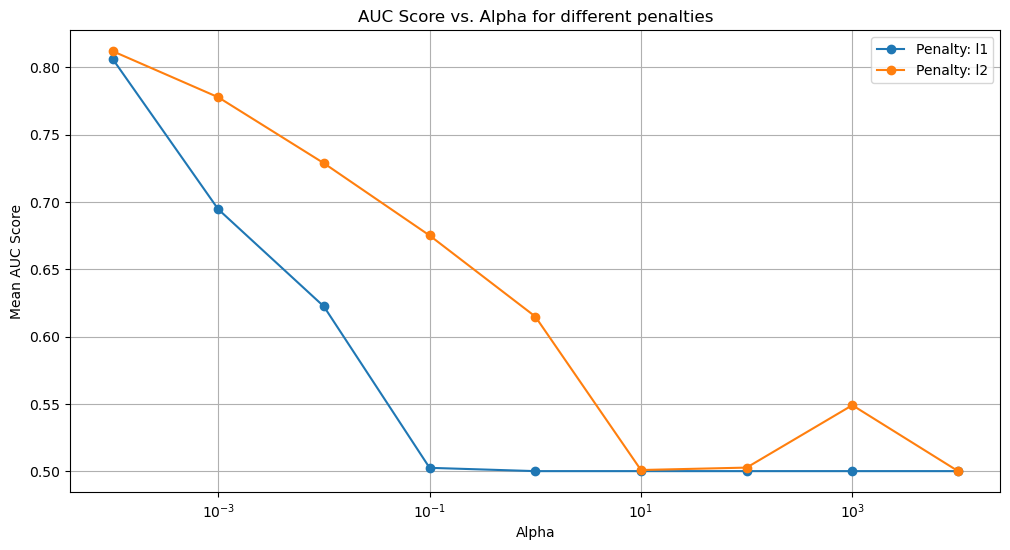

In [187]:
# Plotting the performance
results = grid_search.cv_results_

plt.figure(figsize=(12, 6))

# Plot AUC score for each alpha value for both penalties
for penalty in ['l1', 'l2']:
    mask = results['param_penalty'] == penalty
    alphas = np.array(results['param_alpha'][mask], dtype=float)
    mean_test_score = results['mean_test_score'][mask]

    plt.plot(alphas, mean_test_score, label=f'Penalty: {penalty}', marker='o')

plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Mean AUC Score')
plt.title('AUC Score vs. Alpha for different penalties')
plt.legend()
plt.grid(True)
plt.show()